In [11]:
import numpy as np
from matplotlib import pyplot as plt
import netCDF4 as nc
from cmocean import cm
from scipy import signal
import seawater as sw
import geopy
import geopy.distance
#from eofs.standard import Eof
import datetime
from datetime import date
from scipy import interpolate
from os import listdir
from os.path import isfile, join
import xarray as xr
from sklearn.decomposition import PCA
import cartopy
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import cartopy.mpl.ticker as cticker
from shapely.geometry import Point, Polygon
from calendar import monthrange
from scipy import stats


def cal_path_position(path,LON1,LON2): #track path
    ####path:(ntimes,x,2)
    ###LON1 and LON2 are boundaries for region of interest with given lon boundaries
    times = path.shape[0]
    path_position = np.zeros(times)
    for k in range(times):
        path_lon = path[k,:,0][np.where(np.isnan(path[k,:,0])==0)]
        path_lat = path[k,:,1][np.where(np.isnan(path[k,:,1])==0)]
        ind = np.where((path_lon>=LON1)&(path_lon<=LON2))[0]
        path_position[k] = np.mean(path_lat[ind[0]:ind[-1]+1])     
    return path_position

def cal_path_length(path,LON1,LON2): #length of gulfstream
    ####path:(ntimes,x,2)
    ###LON1 and LON2 are boundaries for region of interest
    times = path.shape[0]
    path_length = np.zeros(times)
    for k in range(times):
        path_lon = path[k,:,0][np.where(np.isnan(path[k,:,0])==0)]
        path_lat = path[k,:,1][np.where(np.isnan(path[k,:,1])==0)]
        ind = np.where((path_lon>=LON1)&(path_lon<=LON2))[0]
        path_lon = path_lon[ind[0]:ind[-1]+1]
        path_lat = path_lat[ind[0]:ind[-1]+1]
        dist1 = 0;
        for p in range(path_lon.size-1):
            x1 = path_lon[p]; x2 = path_lon[p+1];
            y1 = path_lat[p]; y2 = path_lat[p+1];
            dist1 = dist1+sw.dist([y1,y2],[x1,x2])[0][0];
        path_length[k] = dist1;
    return path_length

def month2year(series):
    ##series(nmonths)
    nmonths = series.shape[0]
    nyears = int(nmonths/12)
    new = np.zeros(nyears)
    for n in range(nyears):
        new[n] = np.mean(series[n*12:(n+1)*12])
    return new

def month2year3d(data):
    ##data(nmonths,nlat,nlon)
    nmonths = data.shape[0]
    nyears = int(nmonths/12)
    new = np.zeros((nyears,data.shape[1],data.shape[2]))
    for n in range(nyears):
        new[n,:,:] = np.mean(data[n*12:(n+1)*12,:,:],axis=0)
    return new
ssh_ds = nc.Dataset('/Users/sydneyperkins/Downloads/SSH_data_downscaling.nc','r')


In [83]:
lat_obs = ssh_ds.variables['lat_roms'][ilat_obs,0];
lon_obs = ssh_ds.variables['lon_roms'][0,ilon_obs]
print(np.min(ssh_ds.variables['lon_roms'][:]), np.max(ssh_ds.variables['lon_roms'][:]))
print(np.min(ssh_ds.variables['lat_roms'][0,:]), np.max(ssh_ds.variables['lat_roms'][:]))
print(ssh_ds.variables['lat_roms'].shape)
print(ssh_ds.variables['lon_roms'].shape)
print(lat_obs.shape)
print(lon_obs.shape)

-81.98236 -35.017643
29.028841 51.979645
(466, 1332)
(466, 1332)
(96,)
(185,)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contourf(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_1326/1770210161.py:26: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  seg = c.collections[0].get_paths()
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_1326/1770210161.py:31: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  path1 = c.collections[0].get_paths()[real].vertices
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/

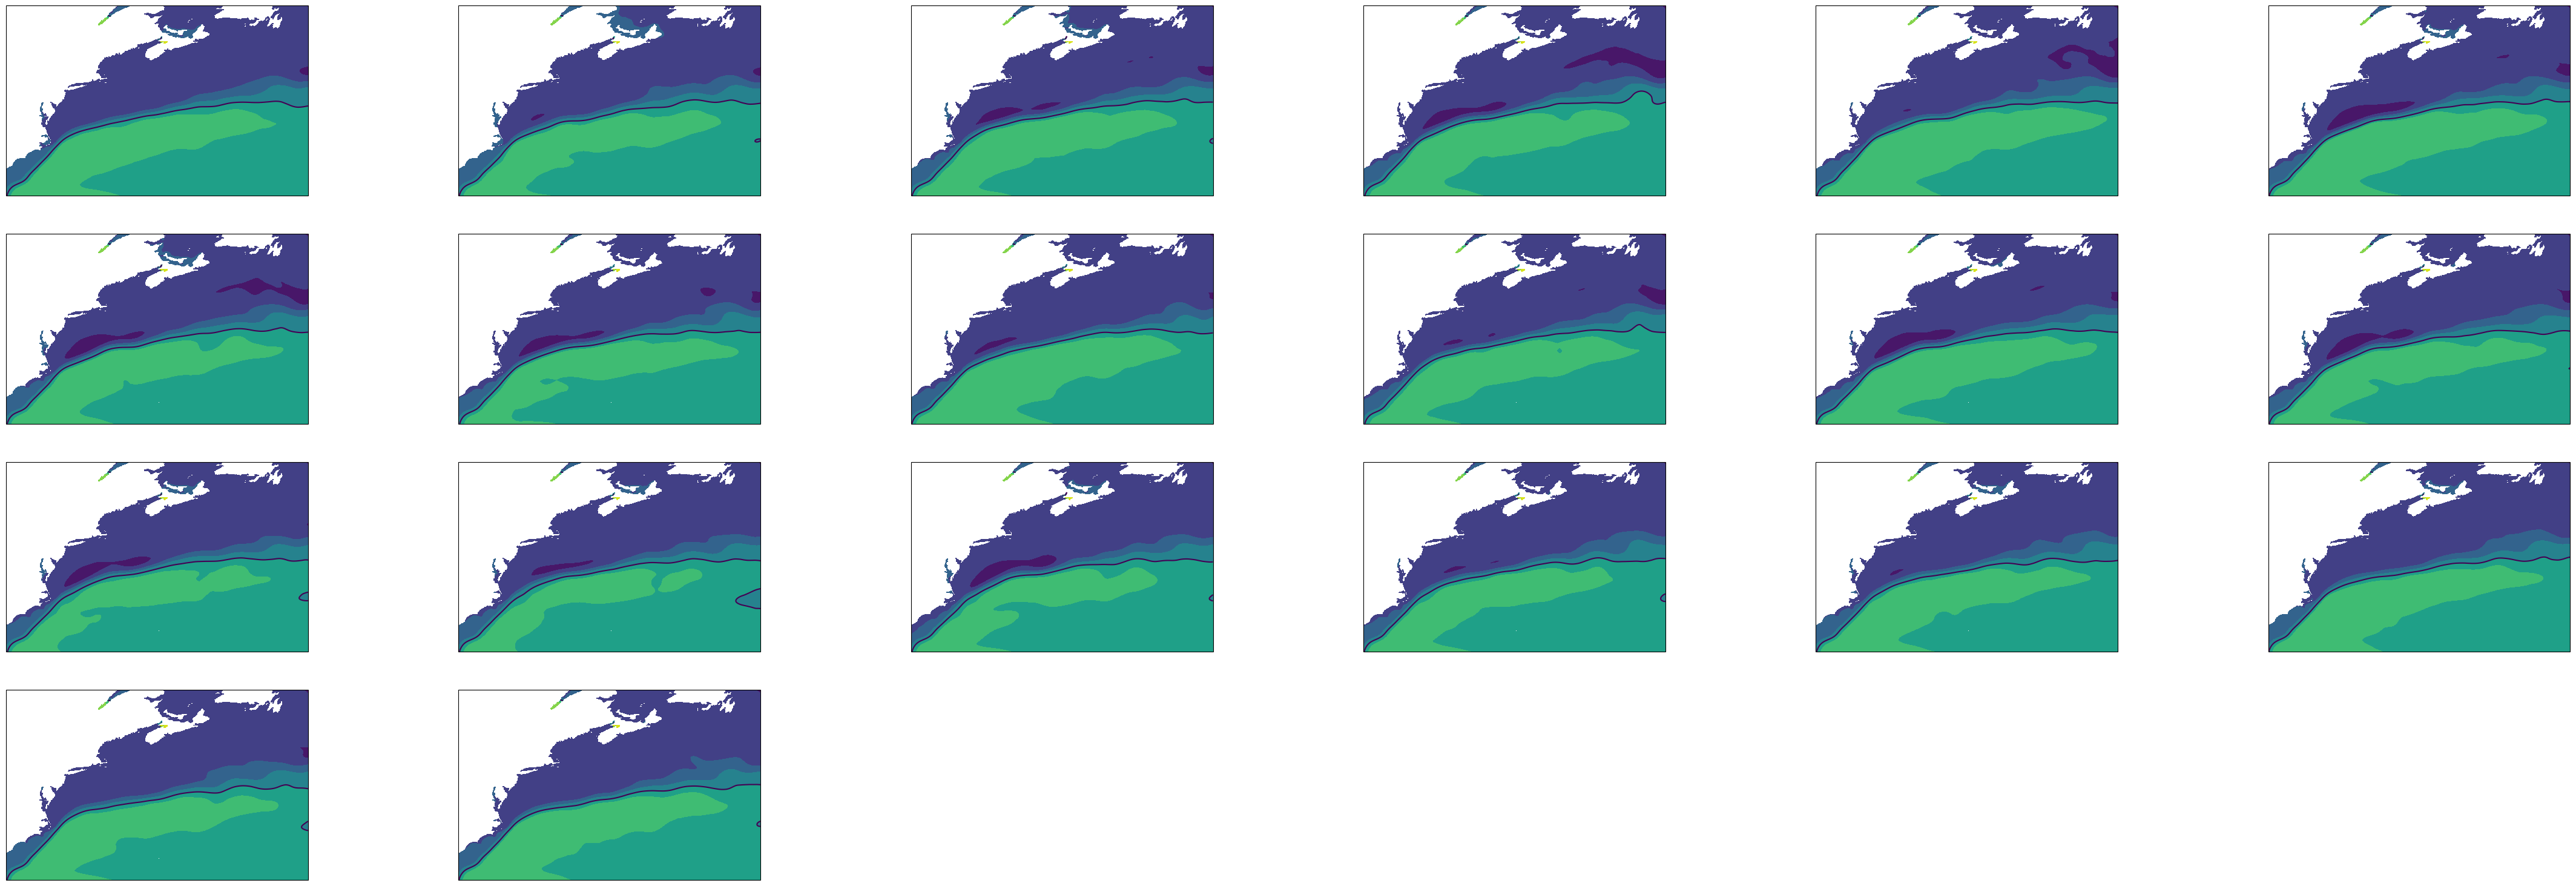

In [119]:
GS_lat1 = 30.125; GS_lat2 = 48.875;
GS_lon1 = 280.125-360; GS_lon2 = 309.875-360;
year1 = 1993; year2 = 2018;
lat0 = ssh_ds.variables['lat_roms'][:,0];
lon0 = ssh_ds.variables['lon_roms'][0,:];
ilat_obs = np.where((lat0>=GS_lat1) & (lat0<=GS_lat2))[0];
ilon_obs = np.where((lon0>=GS_lon1) & (lon0<=GS_lon2))[0];
#ssh_dataset = nc.Dataset('/Volumes/Yiming91977/Global_SSH_AVISO/Global_MONTHLY_SSH_1993_2020.nc','r')
ssh_obs_roms = ssh_ds.variables['ssh_roms'][0:(year2-year1+1)*12,0, ilat_obs,ilon_obs];
ssh_obs_glorys = ssh_ds.variables['ssh_glorys'][0:(year2-year1+1)*12,0, ilat_obs,ilon_obs];
ssh_dple = ssh_ds.variables['ssh_dple40'][0:(year2-year1+1)*12,0, ilat_obs,ilon_obs];
ssh_obs[np.where(abs(ssh_obs)>10)] = np.nan
ssh_obs_mean = np.mean(ssh_obs,axis=0)
lat_obs = ssh_ds.variables['lat_roms'][ilat_obs,0];
lon_obs = ssh_ds.variables['lon_roms'][0,ilon_obs];
nyears_obs = int(year2-year1+1)
nmonths_obs = ssh_obs.shape[0];
path_obs = np.nan*np.zeros((ssh_obs.shape[0],2000,2));   ####320 is for the longest path
ax_obs = 0.0
fig = plt.figure(figsize = (56.25,18.75)); fs=15;

for k in range(ssh_obs.shape[0]):
    m=fig.add_subplot(4,6,k+1,projection=ccrs.PlateCarree(central_longitude=-180))
    plt.contourf(lon_obs, lat_obs, ssh_obs[k,:,:],color = 'seismic')
    c = plt.contour(lon_obs,lat_obs,ssh_obs[k,:,:],levels=[ax_obs],color = 'seismic')
    seg = c.collections[0].get_paths()
    length = np.zeros(len(seg))
    for p in range(len(seg)):
        length[p] = seg[p].vertices.shape[0];
    real = np.where(length==max(length))[0][0]   ####choose the real path
    path1 = c.collections[0].get_paths()[real].vertices
    path_obs[k,0:path1.shape[0],:] = path1
    #plt.close();

SI_obs = cal_path_position(path_obs,LON1=285-360,LON2=290-360)
SIa_obs = month2year((SI_obs-np.mean(SI_obs))/np.std(SI_obs));
PI_obs = cal_path_position(path_obs,LON1=lon_obs[0],LON2=lon_obs[-1])
PIa_obs = month2year((PI_obs-np.mean(PI_obs))/np.std(PI_obs));

length_obs = cal_path_length(path_obs,LON1=lon_obs[0],LON2=lon_obs[-1])
length_obs = month2year((length_obs-np.mean(length_obs))/np.std(length_obs))


/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_1326/3944979170.py:3: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  seg = c.collections[0].get_paths()
/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_1326/3944979170.py:8: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  path1 = c.collections[0].get_paths()[real].vertices


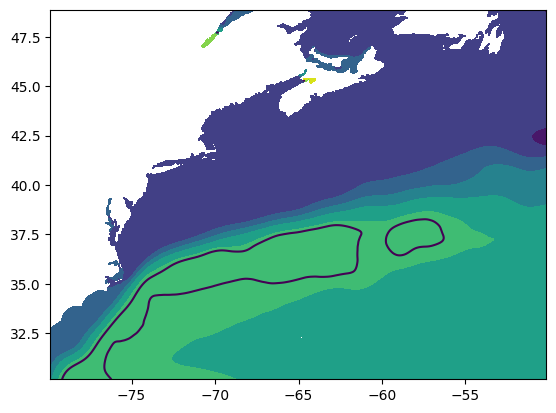

In [93]:
plt.contourf(lon_obs, lat_obs, ssh_obs[0,:,:])
c = plt.contour(lon_obs,lat_obs,ssh_obs[0,:,:],levels=[ax_obs])
seg = c.collections[0].get_paths()
length = np.zeros(len(seg))
for p in range(len(seg)):
    length[p] = seg[p].vertices.shape[0];
real = np.where(length==max(length))[0][0]   ####choose the real path
path1 = c.collections[0].get_paths()[real].vertices
path_obs[k,0:path1.shape[0],:] = path1

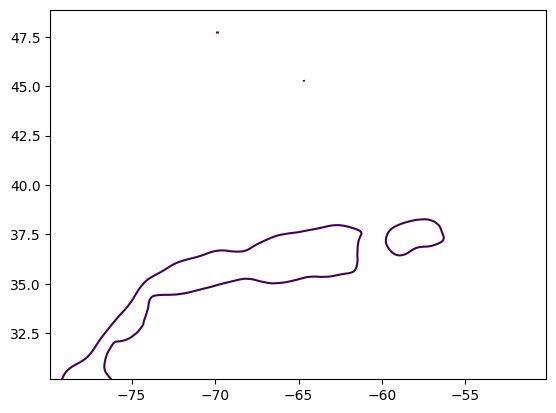

In [86]:
plt.contour(lon_obs,lat_obs,ssh_obs[0,:,:],levels=[ax_obs])

In [223]:
delta_lat = np.gradient(lat_obs)
delta_lat = delta_lat[:,np.newaxis]
delta_lon = np.gradient(lon_obs)
delta_lon = delta_lon[np.newaxis,:]


In [288]:
print(lat_obs.shape)

(372,)


In [292]:
lat_test = lat_obs
mask = np.ma.getmaskarray(lat_obs) 
expanded_mask = (
    mask
    | np.roll(mask, 1)
    | np.roll(mask, -1)
) #finding neigbors 
expanded_mask[0] = mask[0] | mask[1]
expanded_mask[-1] = mask[-1] | mask[-2] # removing error from edge values 

lat_clean = lat_obs[~expanded_mask] 
# the ~ makes it so that it reverse of expanded so it is saying lat_obs where it is NOT masked makes up lat_clean
# for k in range(lat_obs.shape[0]):
#     np.ma.is_Masked(lat_obs[k]);
#     np.ma.is_Masked(lat_obs[k-1]);
#    # np.ma.isMaskedArray(lat_obs[k+1])
#     if True in lat_test: lat_test.remove(True)
print(np.sum(mask) == 0)

True


In [291]:
print(lat_clean)

[30.176756 30.233809 30.290827 30.34781  30.404762 30.461681 30.518568
 30.57542  30.632238 30.689024 30.745777 30.802494 30.85918  30.915833
 30.97245  31.029036 31.085587 31.142103 31.198587 31.255037 31.311455
 31.367836 31.424185 31.480501 31.536781 31.593029 31.649242 31.705421
 31.761566 31.817678 31.873755 31.929798 31.985807 32.041782 32.09772
 32.15363  32.2095   32.26534  32.32114  32.37691  32.432644 32.488346
 32.54401  32.599644 32.65524  32.7108   32.76633  32.821823 32.87728
 32.932705 32.988094 33.04345  33.098766 33.154053 33.2093   33.264515
 33.3197   33.374844 33.42995  33.485027 33.54007  33.595074 33.650043
 33.70498  33.75988  33.814743 33.86957  33.924366 33.979126 34.03385
 34.08854  34.143192 34.19781  34.252396 34.306942 34.361454 34.41593
 34.47037  34.524776 34.579147 34.63348  34.68778  34.742043 34.796272
 34.850464 34.90462  34.95874  35.012825 35.066875 35.120888 35.174866
 35.22881  35.282715 35.336586 35.39042  35.444218 35.49798  35.551704
 35.605396

In [295]:
lat_test = lat_obs
mask = np.ma.getmaskarray(lon_obs) 
expanded_mask = (
    mask
    | np.roll(mask, 1)
    | np.roll(mask, -1)
) #finding neigbors 
expanded_mask[0] = mask[0] | mask[1]
expanded_mask[-1] = mask[-1] | mask[-2]
lon_clean = lon_obs[~expanded_mask] 
print(lon_clean.shape)


(843,)
True


In [224]:
f = 2* 465.2* np.sin(lat_obs*(np.pi/180))

In [225]:
print(ssh_roms.shape)

(372, 843)


In [226]:
print(delta_lon.shape)
print(partial_lat[0,:].shape)
print(delta_lat.shape)
print(partial_lon[:,0].shape)
print(ssh_roms.shape)
print(f.shape)

(1, 843)
(843,)
(372, 1)
(372,)
(372, 843)
(372,)


In [229]:
delta_lat = np.gradient(lat_obs)
delta_lat = delta_lat[:,np.newaxis]
delta_lon = np.gradient(lon_obs)
delta_lon = delta_lon[np.newaxis,:]
ssh_roms = ssh_obs_roms[0,:,:]
partial_lat = np.gradient(ssh_roms, axis = 1)
partial_lon = np.gradient(ssh_roms, axis = 0)
g= 9.81
f = 2* 465.2* np.sin(lat_obs*(np.pi/180))
f = f[:, np.newaxis]
#I need f to index and multiply by the lon associated with various lat

In [251]:
print(speed_v.shape)

(372, 843)


In [252]:
speed_v = (partial_lat/delta_lon)*(g/f)
speed_u = (partial_lon/delta_lat)*(-g/f)
speed_v_sq = speed_v*speed_v
speed_u_sq = speed_u*speed_u

speed = np.sqrt(speed_v_sq+speed_u_sq)

/var/folders/n4/nk6k_c65111dd1zq088dqpb40000gn/T/ipykernel_1326/3491908310.py:6: RuntimeWarning: invalid value encountered in sqrt
  speed = np.sqrt(speed_v_sq+speed_u_sq)


In [256]:
print(np.isnan(speed_u).any(), np.isnan(speed_v).any())
print(np.isinf(speed_u).any(), np.isinf(speed_v).any())
print(np.isinf(speed).any())
print(np.isnan(speed).any())
print(speed.max())
print(speed_u.dtype, speed_v.dtype)

False False
False False
False
False
0.19887005761428536
float64 float64


In [258]:
import numpy as np

with np.errstate(invalid='raise'):
    speed = np.sqrt(speed_u**2 + speed_v**2)

FloatingPointError: invalid value encountered in sqrt

In [259]:
print(np.ma.isMaskedArray(speed_u))

True


In [1]:
ssh = ds['ssh_glorys'[1,0,:,:]
lat_roms = ds['lat_roms'][:]
lon_roms = ds['lon_roms'][:]
plt.contourf(lon,lat, ssh, np.linspace(-1,1,21), cmap= 'seismic', extend = 'both');plt.colorbar();
#narrow white band is the gulf stream

SyntaxError: '[' was never closed (1394549574.py, line 1)

IndentationError: expected an indented block after 'for' statement on line 2 (1123258488.py, line 3)